# Notebook 6 — Detecting Fake Images: The Forensic Toolkit

**Digital Humanities · Image Processing for Museums & Cultural Heritage**

In Notebook 5 we became forgers; now we become detectives. We'll examine
the very fakes we created (in `data/fakes/`) with the standard digital
image forensics toolkit:

1. **The trained eye** — what humans can still catch
2. **Metadata forensics** — EXIF data and its absence; C2PA Content Credentials
3. **Error Level Analysis (ELA)** — JPEG compression inconsistencies
4. **Noise analysis** — every camera leaves a fingerprint
5. **Copy–move detection** — finding cloned regions automatically
6. **Frequency analysis (FFT)** — the spectral signature of AI generators
7. **AI vs AI** — neural networks that detect neural networks
8. **Limits & the provenance alternative** — why detection alone can't win

> Run Notebook 5 first so `data/fakes/` contains the test images.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

DATA = Path("..") / "data" / "raw"
FAKES = Path("..") / "data" / "fakes"

available = sorted(p.name for p in FAKES.glob("*.jpg"))
print("Fakes available for analysis:", available)

Fakes available for analysis: ['ai_renaissance_portrait.jpg', 'gothic_spliced.jpg', 'louvre_inpainted.jpg', 'stonehenge_copymove.jpg']


## 1. The trained eye

Before any algorithm, look. Known weak spots of AI generators (2024–2026):

- **Hands & fingers** — counts and joints often wrong
- **Text & writing** — letters dissolve into pseudo-script (deadly for
  manuscripts and inscriptions!)
- **Symmetry & repetition** — earrings that don't match, irregular
  architectural patterns that should repeat
- **Physics** — inconsistent shadows, impossible reflections
- **Too-perfect texture** — skin/canvas/stone with no natural blemishes

For *manipulated* (rather than generated) photos: lighting direction,
perspective mismatches, blurred boundaries around objects.

But human accuracy on good fakes is barely above chance — studies put it
at 55–65%. We need instruments.

## 2. Metadata forensics: the file's paper trail

Every camera writes **EXIF metadata**: device, date, settings, sometimes
GPS. Forgeries and AI images typically have *none* — or worse,
*contradictory* metadata. Absence proves nothing (uploading to social
media strips EXIF too), but it's the first question to ask.

In [2]:
from PIL.ExifTags import TAGS

def show_exif(path):
    img = Image.open(path)
    exif = img.getexif()
    print(f"— {path.name} —")
    if not exif:
        print("   no EXIF metadata at all\n")
        return
    for tag_id, value in list(exif.items())[:8]:
        print(f"   {TAGS.get(tag_id, tag_id)}: {str(value)[:60]}")
    print()

show_exif(DATA / "louvre_crowd.jpg")        # a real photograph
show_exif(FAKES / "gothic_spliced.jpg")     # our forgery

— louvre_crowd.jpg —
   no EXIF metadata at all

— gothic_spliced.jpg —
   no EXIF metadata at all



The **C2PA / Content Credentials** standard goes further: cameras (Leica,
Sony), Adobe tools, and some AI generators now *cryptographically sign*
an image's full edit history. You can inspect any image at
[contentcredentials.org/verify](https://contentcredentials.org/verify).
Museums and news agencies are early adopters — this is provenance
thinking, which curators already understand deeply, applied to pixels.

## 3. Error Level Analysis (ELA)

JPEG compression is *lossy*: each save discards a little information.
**ELA** re-saves the image at a known quality and visualizes the
difference. Regions that were pasted in (with a different compression
history) respond differently — they glow against the background.

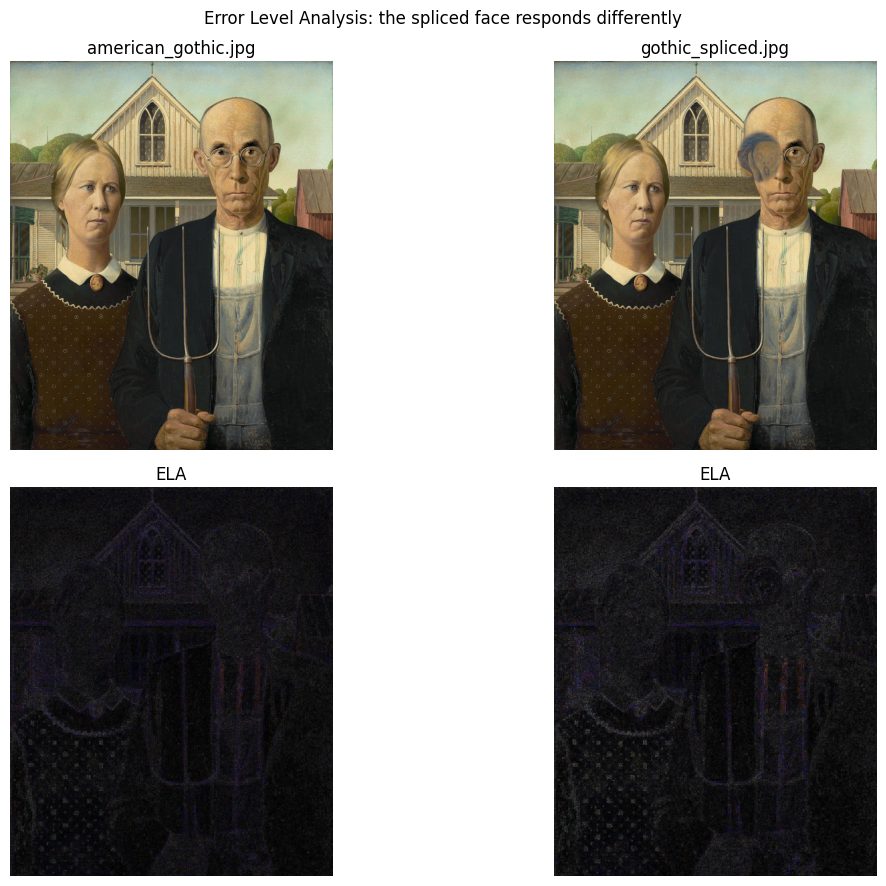

In [3]:
def ela(path, quality=90, scale=15):
    """Error Level Analysis: difference between an image and its re-saved self."""
    original = Image.open(path).convert("RGB")
    tmp = path.parent / "_ela_tmp.jpg"
    original.save(tmp, quality=quality)
    resaved = Image.open(tmp)
    diff = np.abs(np.array(original, dtype=np.int16) -
                  np.array(resaved, dtype=np.int16))
    tmp.unlink()
    return np.clip(diff * scale, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for col, path in enumerate([DATA / "american_gothic.jpg",
                            FAKES / "gothic_spliced.jpg"]):
    axes[0, col].imshow(Image.open(path))
    axes[0, col].set_title(path.name); axes[0, col].axis("off")
    axes[1, col].imshow(ela(path))
    axes[1, col].set_title("ELA"); axes[1, col].axis("off")
plt.suptitle("Error Level Analysis: the spliced face responds differently")
plt.tight_layout(); plt.show()

Reading ELA takes practice: edges and high-contrast detail *always* show
some response. What you're looking for is a **region whose error level is
inconsistent with similar textures elsewhere** — like the pasted face here.

## 4. Noise analysis: the camera's fingerprint

Every sensor produces a characteristic noise pattern, uniform across the
frame. If we subtract a denoised version from the image, what remains is
(mostly) that noise. A spliced region imported from another photo carries
**foreign noise** — visibly different texture in the residual.

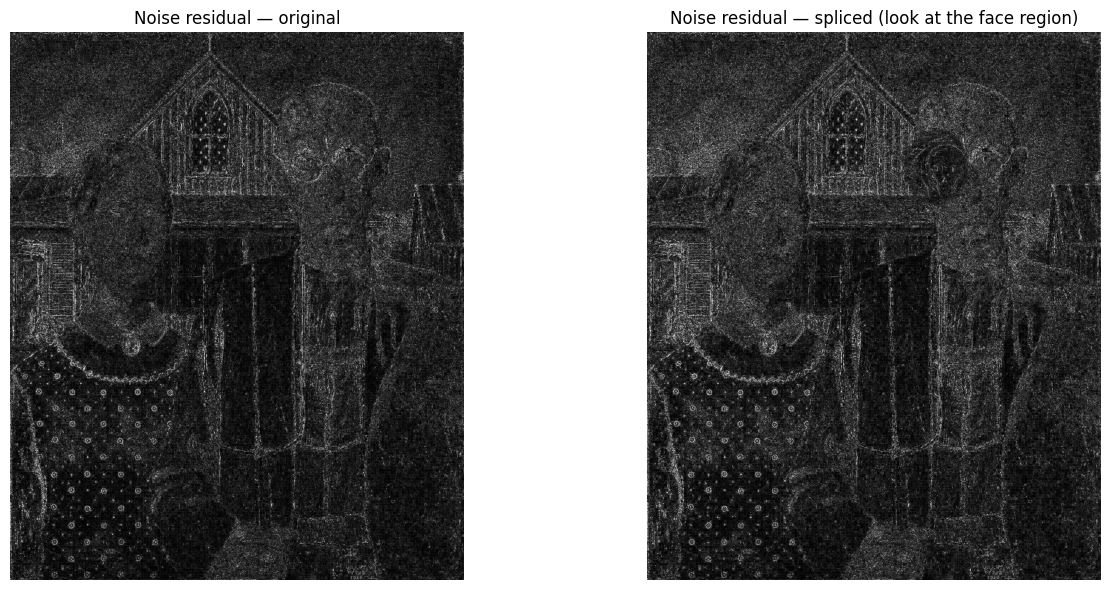

In [4]:
def noise_residual(path, ksize=3, scale=8):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    denoised = cv2.medianBlur(img, ksize)
    residual = cv2.absdiff(img, denoised)
    return np.clip(residual.astype(np.int16) * scale, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(noise_residual(DATA / "american_gothic.jpg"), cmap="gray")
axes[0].set_title("Noise residual — original")
axes[1].imshow(noise_residual(FAKES / "gothic_spliced.jpg"), cmap="gray")
axes[1].set_title("Noise residual — spliced (look at the face region)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

Research-grade tools push this further with **PRNU analysis** (Photo
Response Non-Uniformity): the noise fingerprint is unique *per physical
camera*, and can even tie a photo to one specific device — used in court.

## 5. Copy–move detection: an image matched against itself

Remember ORB feature matching from Notebook 2? Brilliant trick: match an
image **against itself**. Normally each keypoint matches only its own
location — but if a region was *cloned*, its keypoints also match the
clone. Pairs of matching keypoints in different places = copy–move
evidence.

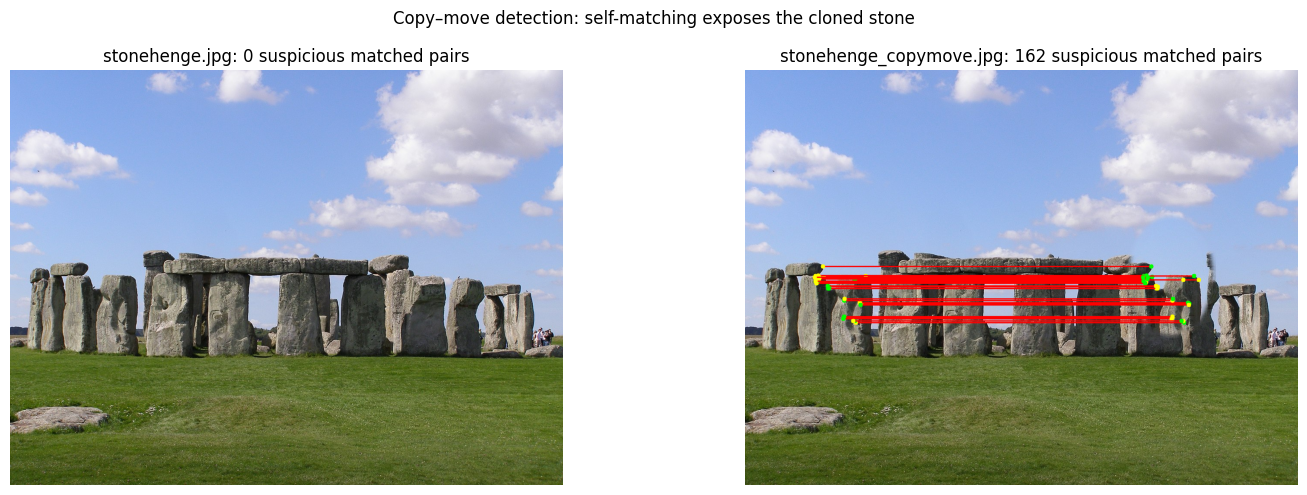

In [5]:
def detect_copy_move(path, min_distance=40, max_pairs=60):
    img = cv2.imread(str(path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create(nfeatures=4000)
    kp, des = orb.detectAndCompute(gray, None)

    # For each keypoint, find its 2 nearest neighbours (1st is itself)
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
    pairs = []
    for m, n in matcher.knnMatch(des, des, k=2):
        p1 = np.array(kp[n.queryIdx].pt)
        p2 = np.array(kp[n.trainIdx].pt)
        # keep strong matches between DISTANT points (i.e. not self-matches)
        if n.distance < 12 and np.linalg.norm(p1 - p2) > min_distance:
            pairs.append((p1, p2))

    vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for p1, p2 in pairs[:max_pairs]:
        cv2.line(vis, tuple(p1.astype(int)), tuple(p2.astype(int)), (255, 0, 0), 2)
        cv2.circle(vis, tuple(p1.astype(int)), 5, (255, 255, 0), -1)
        cv2.circle(vis, tuple(p2.astype(int)), 5, (0, 255, 0), -1)
    return vis, len(pairs)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, path in zip(axes, [DATA / "stonehenge.jpg",
                           FAKES / "stonehenge_copymove.jpg"]):
    vis, n = detect_copy_move(path)
    ax.imshow(vis); ax.axis("off")
    ax.set_title(f"{path.name}: {n} suspicious matched pairs")
plt.suptitle("Copy–move detection: self-matching exposes the cloned stone")
plt.tight_layout(); plt.show()

## 6. Frequency analysis: the spectral fingerprint of AI

The **Fourier transform** re-describes an image as a sum of wave patterns.
Camera photos have a smooth, radially decaying spectrum. Generators
(GANs especially, diffusion models too) often leave **periodic artifacts**
from their upsampling layers — visible as gridlike patterns or anomalous
structure in the spectrum.

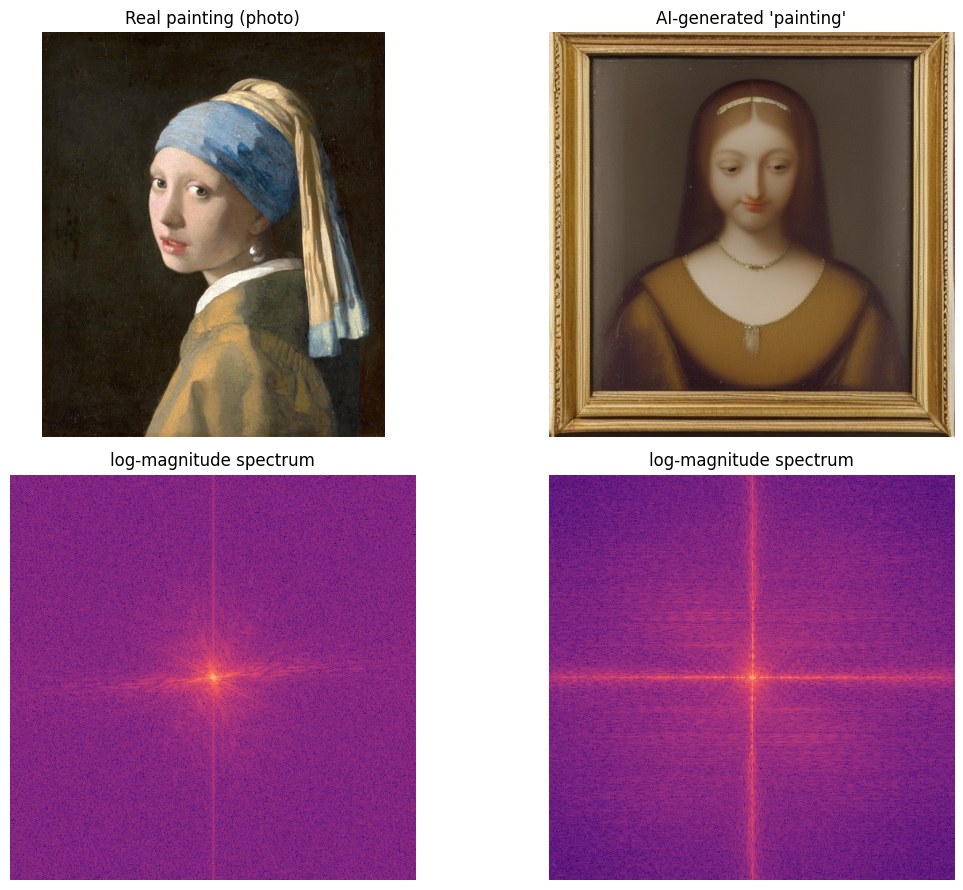

In [6]:
def spectrum(path, size=512):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (size, size)).astype(np.float32)
    fft = np.fft.fftshift(np.fft.fft2(img))
    return np.log1p(np.abs(fft))

ai_file = FAKES / "ai_renaissance_portrait.jpg"
compare = [(DATA / "girl_pearl_earring.jpg", "Real painting (photo)")]
if ai_file.exists():
    compare.append((ai_file, "AI-generated 'painting'"))
else:
    print("Run the diffusion cell in Notebook 5 to add the AI image here.")

fig, axes = plt.subplots(2, len(compare), figsize=(6 * len(compare), 9))
axes = axes.reshape(2, -1)
for col, (path, title) in enumerate(compare):
    axes[0, col].imshow(Image.open(path)); axes[0, col].set_title(title)
    axes[1, col].imshow(spectrum(path), cmap="magma")
    axes[1, col].set_title("log-magnitude spectrum")
    for row in range(2): axes[row, col].axis("off")
plt.tight_layout(); plt.show()

Don't over-read a single spectrum — JPEG compression also adds blockiness
(8×8 grid spikes). Forensic systems compare statistics across thousands of
images; visually, look for unusually regular star/grid patterns.

## 7. AI vs AI: neural fake detectors

The final tool: train a classifier on millions of real and generated
images, and let it judge. We'll use an open pretrained detector from
Hugging Face.

> ⚠️ Treat the output as a *hint*, never a verdict. Detectors lag behind
> new generators, degrade on resized/compressed images, and produce both
> false alarms and misses. This is an **arms race** (literally the GAN
> training loop from Notebook 5, played out across the whole internet).

Device set to use cpu


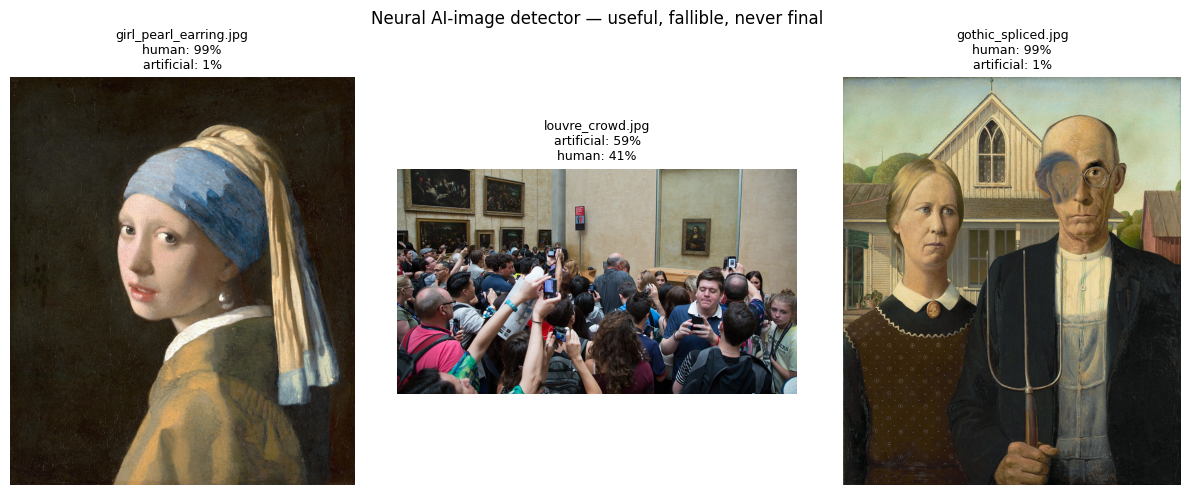

In [4]:
import torch
from transformers import pipeline

device_idx = 0 if torch.cuda.is_available() else -1
detector = pipeline("image-classification",
                    model="umm-maybe/AI-image-detector",
                    device=device_idx)

test_files = [DATA / "girl_pearl_earring.jpg",
              DATA / "louvre_crowd.jpg",
              FAKES / "gothic_spliced.jpg"]
# if ai_file.exists():
#     test_files.append(ai_file)

fig, axes = plt.subplots(1, len(test_files), figsize=(4.2 * len(test_files), 5))
for ax, path in zip(axes, test_files):
    img = Image.open(path).convert("RGB")
    scores = {r["label"]: r["score"] for r in detector(img)}
    ax.imshow(img); ax.axis("off")
    verdict = "\n".join(f"{k}: {v:.0%}" for k, v in scores.items())
    ax.set_title(f"{path.name}\n{verdict}", fontsize=9)
plt.suptitle("Neural AI-image detector — useful, fallible, never final")
plt.tight_layout(); plt.show()

Note what this detector can and cannot do: it targets **fully AI-generated**
images. Our *spliced* photo is mostly real pixels, so a generation detector
may pass it — that's why the forensic toolkit has six tools, not one.

## 8. The honest conclusion: detection has limits

| Technique | Catches | Defeated by |
|---|---|---|
| Eye / artifacts | sloppy fakes | better models, care |
| EXIF metadata | naive fakes | metadata editors, stripping |
| ELA | splices, edits | uniform re-compression, screenshots |
| Noise analysis | splices | noise matching, heavy compression |
| Copy–move (ORB) | clones | rotation+scaling of clone, smoothing |
| FFT spectrum | older GANs | newer architectures |
| Neural detectors | known generators | next year's generator |

Every tool detects *yesterday's* fakes. That's why the field is shifting
from **detection** ("prove it's fake") to **provenance** ("prove it's
real"): C2PA signatures at capture time, hash registries, documented
chains of custody — concepts museums have practiced for centuries under
the name *provenance research*. Digital humanists are unusually well
prepared for this future.

## ✏️ Final exercises & project ideas

1. Run the full toolkit on **your own forgery** from Notebook 5's
   exercise 1. Which tools catch it? Which fail?
2. Take a real photo, send it through WhatsApp/social media (compression!),
   and re-run ELA and the neural detector. What survives?
3. **Mini-project**: build a `verify_image(path)` function that runs
   metadata, ELA, copy–move, and the neural detector, and prints a one-page
   "forensic report". Discuss: what language should the report use —
   "fake" or "inconsistencies detected"?
4. **Essay topic**: "The museum as an institution of authenticity in the
   age of generative AI." Use the technical limits in the table above as
   evidence.